### Imports

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score

import shap
from lime.lime_tabular import LimeTabularExplainer


### Load Dataset

In [47]:
# Load cleaned Titanic dataset
data = pd.read_csv("../data/titanic_clean.csv")

X = data.drop("Survived", axis=1)
y = data["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [48]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')#strategy='mean'strategy='most_frequent'

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

### Train models

In [49]:
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42)

rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

print("RF Accuracy:", accuracy_score(y_test, rf.predict(X_test)))
print("GB Accuracy:", accuracy_score(y_test, gb.predict(X_test)))


RF Accuracy: 0.8044692737430168
GB Accuracy: 0.8100558659217877


### SHAP Interpretability

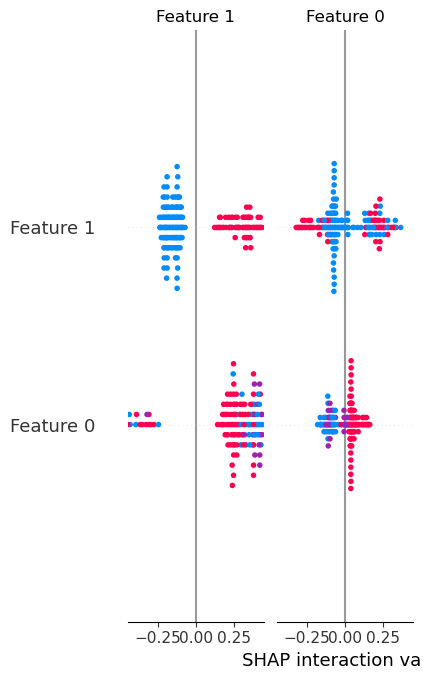

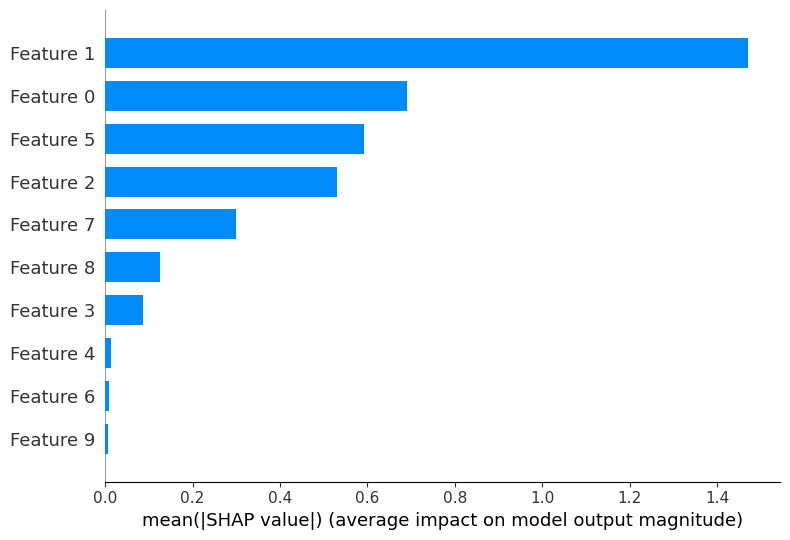

In [50]:
# Random Forest SHAP
explainer_rf = shap.TreeExplainer(rf)
shap_values_rf = explainer_rf.shap_values(X_test)

# Fix shape issue
if isinstance(shap_values_rf, list):
    shap.summary_plot(shap_values_rf[1], X_test, plot_type="bar")
else:
    shap.summary_plot(shap_values_rf, X_test, plot_type="bar")

# Gradient Boosting SHAP
explainer_gb = shap.TreeExplainer(gb)
shap_values_gb = explainer_gb.shap_values(X_test)

# Fix shape issue
if len(shap_values_gb.shape) == 3:
    shap.summary_plot(shap_values_gb[:, :, 1], X_test, plot_type="bar")
else:
    shap.summary_plot(shap_values_gb, X_test, plot_type="bar")

### LIME Interpretability

[('Sex <= 0.00', -0.3964591680228832), ('2.00 < Pclass <= 3.00', -0.08204061737372048), ('0.00 < Embarked_S <= 1.00', -0.05383428338861301), ('-0.57 < Age <= -0.10', -0.031923476265155216), ('FamilySize > 2.00', -0.020100352561497333)]


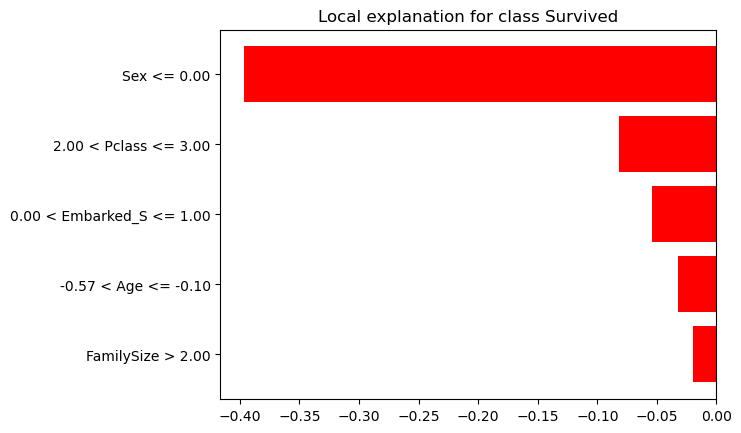

In [51]:
# LIME explainer
# If X_train is already converted to NumPy array,
# feature_names must be supplied separately

feature_names = [
    "Pclass", "Sex", "Age", "SibSp", "Parch",
    "Fare", "Embarked_Q", "Embarked_S" , "FamilySize", "IsAlone"
]  # replace with your actual column names

explainer = LimeTabularExplainer(
    training_data=X_train,
    feature_names=feature_names,
    class_names=["Not Survived", "Survived"],
    mode="classification"
)

# Explain one test instance
exp = explainer.explain_instance(
    X_test[0],          # use indexing if X_test is NumPy array
    rf.predict_proba,
    num_features=5
)

print(exp.as_list())
fig = exp.as_pyplot_figure()


### Model Interpretability

We applied SHAP and LIME to explain predictions:

- **SHAP**: Showed global feature importance. Age_bin, Pclass, and Fare were strong predictors.
- **LIME**: Explained individual predictions, highlighting which features pushed survival probability up or down.

**Findings:**
- SHAP confirmed engineered features (Day 16) added predictive power.
- LIME demonstrated case-by-case reasoning, useful for transparency.

**Conclusion:**  
Interpretability tools provide trust and transparency. SHAP is best for global insights, while LIME excels at local explanations.
